https://rhodesmill.org/skyfield/toc.html

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
%matplotlib widget

import scipy
import skyfield as sf
from skyfield.api import *
import skyfield.positionlib as poslib
from tle_parser import TLE
from datetime import datetime, timezone
from multilateration import solve_multilateration

In [2]:
from scipy.constants import speed_of_light as c

In [3]:
ts = load.timescale()

time_0 = datetime(2026, 4, 25, 12, 0, 0, tzinfo=timezone.utc)
time_1 = datetime(2026, 4, 25, 21, 20, 0, tzinfo=timezone.utc)
time_2 = datetime(2026, 4, 25, 21, 30, 0, tzinfo=timezone.utc)

tle = TLE.from_orbital_parameters(
epoch=time_0,
inclination_deg=90.0,
raan_deg=15,
eccentricity=0.0005,
argument_of_perigee_deg=80.0,
mean_anomaly_deg=20.0,
mean_motion_rev_per_day=15.5
)
  
satellite = EarthSatellite(tle.line1, tle.line2, f'Dummy Sat', ts)
t = ts.linspace(ts.from_datetime(time_1), ts.from_datetime(time_2), 1000)  # 1000 time points over the next hour
sat_xyz = satellite.at(t).subpoint().itrs_xyz.km

In [4]:
gs_lat_lon_list = [(50 * N, 20 * E), (50 * N, 22 * E), (52 * N, 22 * E), (52 * N, 20 * E)]
gs_wgs_list = [wgs84.latlon(lat, lon) for lat, lon in gs_lat_lon_list]
gs_xyz_list = [gs.at(t).itrf_xyz().km for gs in gs_wgs_list]
gs_positions = [gs.at(t).position.km for gs in gs_wgs_list]

Text(0.5, 0.92, 'Satellite Path and Ground Stations')

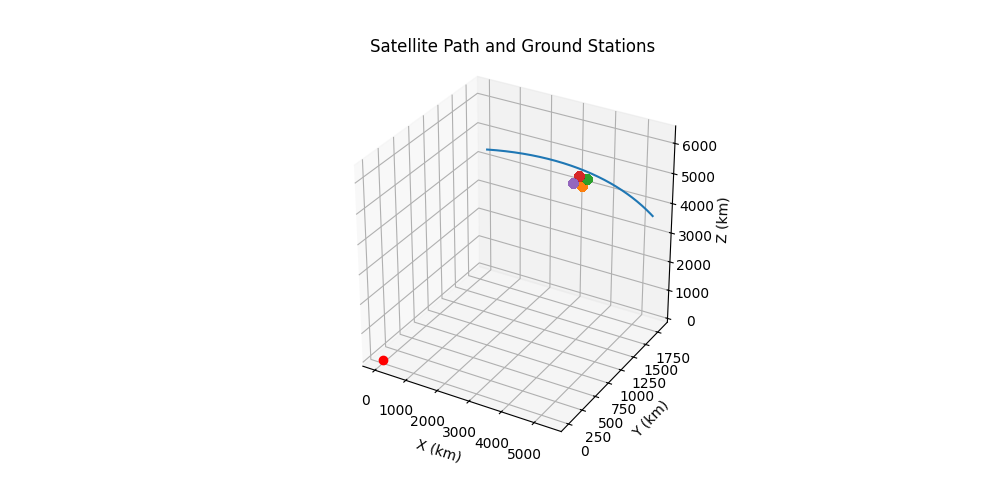

In [5]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection='3d')
ax.set_aspect('equal')

ax.plot([0], [0], [0], 'ro', label='Earth Center')
ax.plot(sat_xyz[0], sat_xyz[1], sat_xyz[2], label='Satellite Path')
for i, gs_xyz in enumerate(gs_xyz_list):
  ax.plot(gs_xyz[0], gs_xyz[1], gs_xyz[2], label=f'Ground Station {i+1}', color=f'C{i+1}', marker='o', linestyle='None')
ax.set_xlabel('X (km)')
ax.set_ylabel('Y (km)')
ax.set_zlabel('Z (km)')
ax.set_title('Satellite Path and Ground Stations')

In [6]:
rs = satellite.at(t).position.km
vs = satellite.at(t).velocity.km_per_s
ra = gs_wgs_list[0].at(t).position.km
rb = gs_wgs_list[1].at(t).position.km
rc = gs_wgs_list[2].at(t).position.km
rd = gs_wgs_list[3].at(t).position.km
ras = rs - ra
rbs = rs - rb
rcs = rs - rc
rds = rs - rd
ras_unit = ras / np.linalg.norm(ras, axis=0)
rbs_unit = rbs / np.linalg.norm(rbs, axis=0)
rcs_unit = rcs / np.linalg.norm(rcs, axis=0)
rds_unit = rds / np.linalg.norm(rds, axis=0)
vas = np.vecdot(ras_unit, vs, axis=0)
vbs = np.vecdot(rbs_unit, vs, axis=0)
vcs = np.vecdot(rcs_unit, vs, axis=0)
vds = np.vecdot(rds_unit, vs, axis=0)
tau_a = np.linalg.norm(ras, axis=0) / c
tau_b = np.linalg.norm(rbs, axis=0) / c
tau_c = np.linalg.norm(rcs, axis=0) / c
tau_d = np.linalg.norm(rds, axis=0) / c

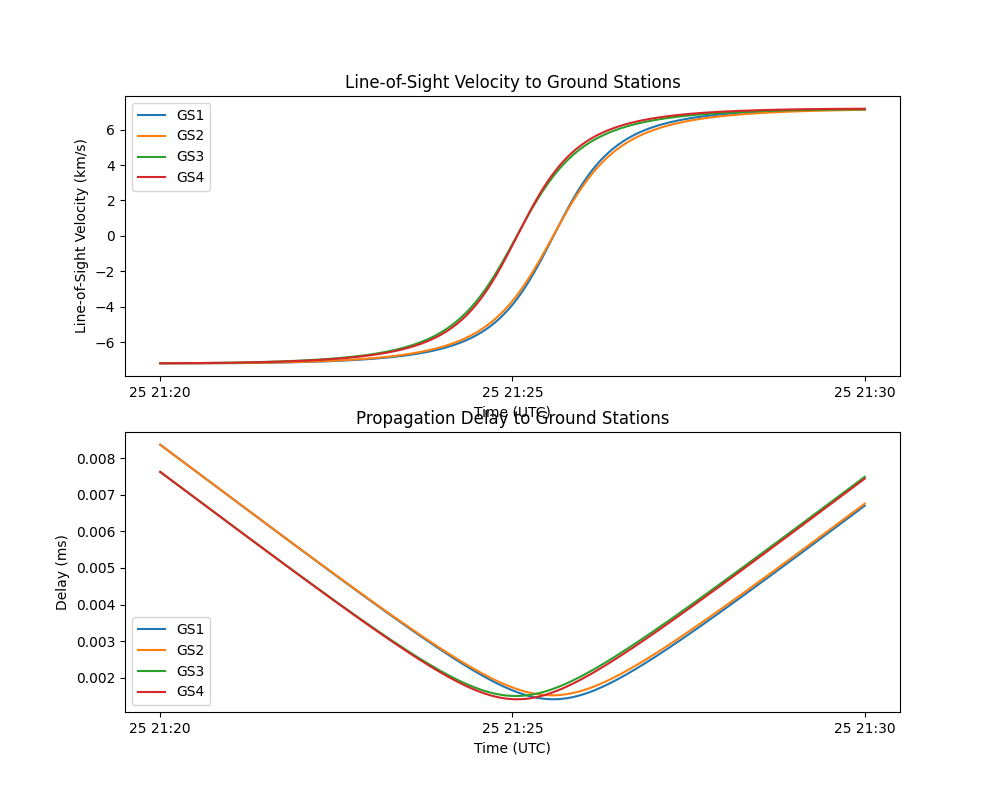

In [7]:
fig = plt.figure(figsize=(10, 8))
ax_vel = fig.add_subplot(211)
ax_tau = fig.add_subplot(212, sharex=ax_vel)
ax_vel.plot(t.utc_datetime(), vas)
ax_vel.plot(t.utc_datetime(), vbs)
ax_vel.plot(t.utc_datetime(), vcs)
ax_vel.plot(t.utc_datetime(), vds)
ax_vel.set_xlabel('Time (UTC)')
ax_vel.set_ylabel('Line-of-Sight Velocity (km/s)')
ax_vel.set_title('Line-of-Sight Velocity to Ground Stations')
ax_vel.legend(['GS1', 'GS2', 'GS3', 'GS4'])
ax_tau.plot(t.utc_datetime(), tau_a * 1e3)
ax_tau.plot(t.utc_datetime(), tau_b * 1e3)
ax_tau.plot(t.utc_datetime(), tau_c * 1e3)
ax_tau.plot(t.utc_datetime(), tau_d * 1e3)
ax_tau.set_xlabel('Time (UTC)')
ax_tau.set_ylabel('Delay (ms)')
ax_tau.set_title('Propagation Delay to Ground Stations')
ax_tau.legend(['GS1', 'GS2', 'GS3', 'GS4'])

In [10]:
ry1 = ras - rbs
ry2 = ras - rcs
ry3 = ras - rds

tau1 = np.linalg.norm(ry1, axis=0) / c
tau2 = np.linalg.norm(ry2, axis=0) / c
tau3 = np.linalg.norm(ry3, axis=0) / c

d1 = vs * ras / np.linalg.norm(ras, axis=0)
d2 = vs * rbs / np.linalg.norm(rbs, axis=0)
d3 = vs * rcs / np.linalg.norm(rcs, axis=0)
d4 = vs * rds / np.linalg.norm(rds, axis=0)

print(d1.shape, d2.shape, d3.shape, d4.shape)

f12 = np.linalg.norm(d1 - d2)
f13 = np.linalg.norm(d1 - d3)
f14 = np.linalg.norm(d1 - d4)

(3, 1000) (3, 1000) (3, 1000) (3, 1000)


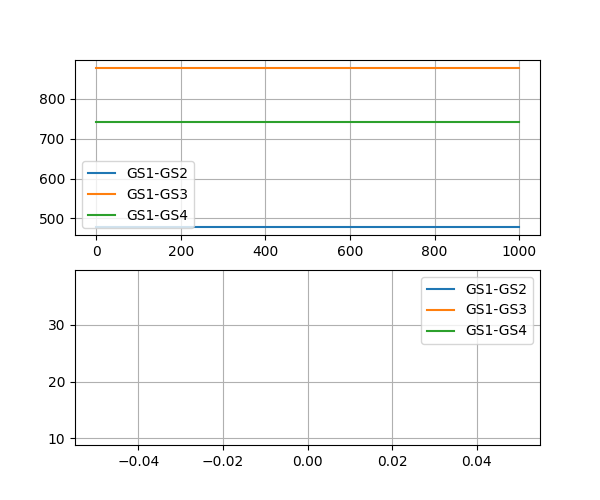

In [11]:
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(211)
ax.plot(tau1 * 1e9, label='GS1-GS2')
ax.plot(tau2 * 1e9, label='GS1-GS3')
ax.plot(tau3 * 1e9, label='GS1-GS4')
ax.legend()
ax.grid(True)

ax = fig.add_subplot(212)
ax.plot(f12, label='GS1-GS2')
ax.plot(f13, label='GS1-GS3')
ax.plot(f14, label='GS1-GS4')
ax.legend()
ax.grid(True)

In [12]:
x, y = np.meshgrid(np.linspace(-10, 10, 100), np.linspace(-10, 10, 100))
x1 = np.array([1, 0])
x2 = np.array([-1, 0])
x3 = np.array([0, 1])

r = np.dstack((x, y))
print(r.shape)

ry1 = r - x1
ry2 = r - x2
ry3 = r - x3

tau1 = np.linalg.norm(ry1, axis=2) / c - np.linalg.norm(ry2, axis=2) / c
tau2 = np.linalg.norm(ry1, axis=2) / c - np.linalg.norm(ry3, axis=2) / c

(100, 100, 2)


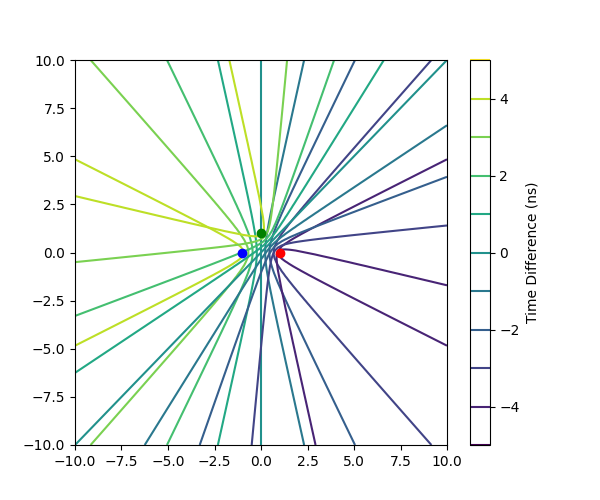

In [13]:
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111)

cf = ax.contour(x, y, tau1 * 1e9, levels=10, cmap='viridis')
cf = ax.contour(x, y, tau2 * 1e9, levels=10, cmap='viridis')
ax.plot(x1[0], x1[1], 'ro', label='GS1')
ax.plot(x2[0], x2[1], 'bo', label='GS2')
ax.plot(x3[0], x3[1], 'go', label='GS3')
fig.colorbar(cf, ax=ax, label='Time Difference (ns)')

In [14]:

v1 = np.array([1, 1])
v2 = np.array([-1, 3])
v3 = np.array([5, 10])

# v1 = v1[np.newaxis, np.newaxis, :]
# v2 = v2[np.newaxis, np.newaxis, :]
# v3 = v3[np.newaxis, np.newaxis, :]

print(v1.shape, ry1.shape, np.linalg.norm(ry1, axis=2).shape)

# d1 = np.vecdot(v1, ry1, axis=2)
d1 = v1.T * ry1 / np.linalg.norm(ry1, axis=2)[:, :, np.newaxis]
d2 = v2.T * ry2 / np.linalg.norm(ry2, axis=2)[:, :, np.newaxis]
d3 = v3.T * ry3 / np.linalg.norm(ry3, axis=2)[:, :, np.newaxis]

print(d1.shape, d2.shape, d3.shape)

f12 = np.linalg.norm(d1 - d2, axis=2)
f13 = np.linalg.norm(d1 - d3, axis=2)


(2,) (100, 100, 2) (100, 100)
(100, 100, 2) (100, 100, 2) (100, 100, 2)


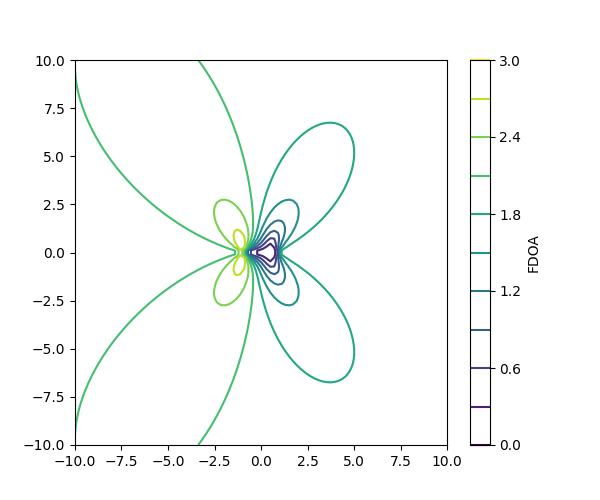

In [15]:
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111)
cf = ax.contour(x, y, f12, levels=10, cmap='viridis')
fig.colorbar(cf, ax=ax, label='FDOA')